In [73]:
import pandas as pd
import signatureanalyzer as sa

In [90]:
maf_sig_df = pd.read_csv('../outputs/ardnmf_output/signature_weighted_maf.tsv', sep='\t')
# SBS signatures only apply to point mutations, so this is the number of SNVs before filtering (excluding indels)
print("Number of mutations before filtering:",len(maf_sig_df))
maf_sig_df.head()


/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_42720/966900347.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  maf_sig_df = pd.read_csv('../outputs/ardnmf_output/signature_weighted_maf.tsv', sep='\t')


Number of mutations before filtering: 1083128


,Hugo_Symbol,Chromosome,Start_position,End_Position,Variant_Classification,Variant_Type,Reference_Allele,Tumor_Seq_Allele1,Tumor_Seq_Allele2,t_alt_count,...,S14-SBS6,S15-Unmatched,S16-SBS31,S17-Unmatched,S18-SBS60,S19-SBS17b,S20-SBS30,S21-SBS13,S22-Unmatched,S23-SBS1
0,Unknown,1,987304,987304,IGR,SNP,A,A,T,5,...,0.000000e+00,2.449551e-19,4.834303e-02,1.783933e-08,0.000000,4.946778e-03,0.0,4.562014e-02,1.537023e-01,7.000000e-44
1,LINC01342,1,1140660,1140660,RNA,SNP,A,A,C,4,...,3.216359e-05,5.809404e-03,9.065238e-03,5.255763e-02,0.129157,3.670996e-01,0.0,4.891274e-25,5.737724e-02,5.990635e-03
2,Unknown,1,1164163,1164163,IGR,SNP,A,A,T,14,...,3.934225e-02,4.705683e-02,1.073980e-02,1.197533e-01,0.012290,7.032219e-21,0.0,0.000000e+00,0.000000e+00,5.175542e-30
3,CFAP74,1,1945872,1945872,Intron,SNP,T,T,G,5,...,1.255921e-21,1.147621e-20,1.115363e-08,0.000000e+00,0.834012,3.217247e-15,0.0,4.536606e-27,8.170678e-23,0.000000e+00
4,MORN1,1,2334354,2334354,Intron,SNP,C,C,T,6,...,9.182856e-02,5.251729e-03,4.771164e-02,6.922000e-42,0.003580,1.214985e-02,0.0,2.205617e-02,5.298599e-02,2.863561e-01


In [91]:
NMF_HDF_PATH = "../outputs/ardnmf_output/nmf_output.h5"
REF = "cosmic3"

# Import reference signatures
ref_df, ref_idx = sa.utils.load_reference_signatures(REF, verbose=False)

# Import result matrices
Wraw = pd.read_hdf(NMF_HDF_PATH, "Wraw")
Wraw.rename(columns={x:x.split('-')[0] for x in Wraw.columns if x.startswith('S')}, inplace=True)
W = pd.read_hdf(NMF_HDF_PATH, "W")
W.rename(columns={x:x.split('-')[0] for x in W.columns if x.startswith('S')}, inplace=True)
Hraw = pd.read_hdf(NMF_HDF_PATH, "Hraw")
Hraw.rename(columns={x:x.split('-')[0] for x in Hraw.columns if x.startswith('S')}, inplace=True)
H = pd.read_hdf(NMF_HDF_PATH, "H")
H.rename(columns={x:x.split('-')[0] for x in H.columns if x.startswith('S')}, inplace=True)
signatures = pd.read_hdf(NMF_HDF_PATH, "signatures")
    
res = {}
res["Wraw"] = Wraw
res["W"] = W
res["Hraw"] = Hraw
res["H"] = H
res["signatures"] = signatures

if REF in ['pcawg_SBS','pcawg_COMPOSITE','pcawg_SBS_ID']:
    Wraw96 = pd.read_hdf(NMF_HDF_PATH, "Wraw96")
    Wraw96.rename(columns={x:x.split('-')[0] for x in Wraw96.columns if x.startswith('S')}, inplace=True)
    res["Wraw96"] = Wraw96

sa.utils.postprocess_msigs(res, ref_df, ref_idx, REF)


In [92]:
res["cosine"]

,S1-Unmatched,S2-SBS18,S3-SBS2,S4-SBS20,S5-SBS12,S6-Unmatched,S7-SBS35,S8-SBS40,S9-Unmatched,S10-Unmatched,...,S14-SBS6,S15-Unmatched,S16-SBS31,S17-Unmatched,S18-SBS60,S19-SBS17b,S20-SBS30,S21-SBS13,S22-Unmatched,S23-SBS1
SBS1,0.040825,0.019330,0.152240,0.003706,0.044839,0.021958,0.010501,0.102963,0.013826,0.015740,...,0.743408,0.020811,0.018717,0.012068,0.038984,0.014976,0.084290,0.012114,0.009162,0.982236
SBS2,0.015861,0.009571,0.850473,0.004354,0.007649,0.359593,0.024156,0.187405,0.002806,0.139037,...,0.072118,0.028036,0.031321,0.001479,0.026848,0.064035,0.404741,0.033557,0.019354,0.038374
SBS3,0.301677,0.319624,0.340173,0.264251,0.481770,0.271787,0.551870,0.864473,0.114055,0.364480,...,0.415711,0.568093,0.350555,0.362544,0.171437,0.210614,0.409133,0.453861,0.237581,0.072624
SBS4,0.075489,0.579463,0.135331,0.518197,0.121334,0.240215,0.460679,0.712655,0.029114,0.290316,...,0.228166,0.414659,0.216475,0.278257,0.062341,0.051980,0.149221,0.109896,0.430574,0.047657
SBS5,0.225744,0.255066,0.447950,0.127288,0.580731,0.280347,0.377951,0.755288,0.107045,0.258124,...,0.651376,0.532840,0.301122,0.432994,0.124324,0.197537,0.548054,0.232262,0.154359,0.203897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SBS58,0.125148,0.131916,0.506139,0.047788,0.243736,0.762454,0.181025,0.514071,0.039888,0.345187,...,0.329720,0.184314,0.163901,0.268420,0.201326,0.134332,0.321444,0.110222,0.189280,0.102521
SBS59,0.021865,0.457955,0.012831,0.039884,0.040527,0.026407,0.106934,0.238090,0.009290,0.030697,...,0.057324,0.381757,0.037561,0.028907,0.025023,0.047774,0.027480,0.012889,0.040714,0.009424
SBS60,0.084401,0.006597,0.008372,0.004155,0.013792,0.195567,0.010792,0.068580,0.139228,0.008963,...,0.015170,0.012678,0.008131,0.035418,0.989269,0.041054,0.008903,0.005650,0.010251,0.012644
SBS84,0.133227,0.097551,0.167790,0.066791,0.079138,0.107802,0.228845,0.368637,0.013747,0.079065,...,0.454505,0.482368,0.247375,0.059107,0.028805,0.037031,0.499968,0.109189,0.028140,0.037314


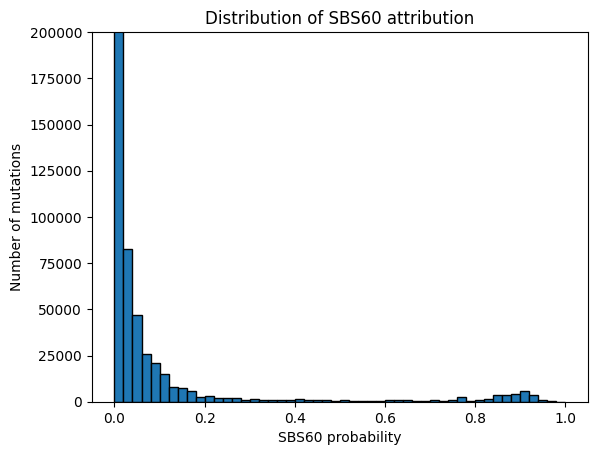

In [93]:
import matplotlib.pyplot as plt

# Plot distribution of SBS60 probabilities
plt.hist(maf_sig_df['S18-SBS60'], bins=50, edgecolor='black')
plt.xlabel('SBS60 probability')
plt.ylabel('Number of mutations')
plt.ylim(0, 200000)
plt.title('Distribution of SBS60 attribution')
plt.show()

In [94]:
for thresh in [0.1, 0.2, 0.3, 0.4, 0.5]:
    n_removed = (maf_sig_df['S18-SBS60'] >= thresh).sum()
    pct = n_removed / len(maf_sig_df) * 100
    print(f"Threshold {thresh}: remove {n_removed:,} mutations ({pct:.2f}%)")

Threshold 0.1: remove 97,766 mutations (9.03%)
Threshold 0.2: remove 58,402 mutations (5.39%)
Threshold 0.3: remove 47,737 mutations (4.41%)
Threshold 0.4: remove 42,004 mutations (3.88%)
Threshold 0.5: remove 37,485 mutations (3.46%)


In [95]:
threshold = 0.2
maf_filtered = maf_sig_df[maf_sig_df['S18-SBS60'] < threshold]
print(f"Kept {len(maf_filtered):,} mutations after artifact filtering")

# create final filtered maf without signature attribution columns (until 'Tumor_Sample_Barcode' column)
maf_filtered = maf_filtered.loc[:, :'Tumor_Sample_Barcode']

# add in the indels
original_maf = pd.read_csv('../data/snv_filtered.maf', sep='\t')
non_snps = original_maf[original_maf['Variant_Type'] != 'SNP']
non_snps = non_snps.rename(columns={'Start_Position': 'Start_position'})
print(f"Non-SNPs to add back: {len(non_snps):,}")

# Combine with filtered SNPs
final_maf = pd.concat([maf_filtered, non_snps], ignore_index=True)

Kept 1,024,726 mutations after artifact filtering
Non-SNPs to add back: 104,574


In [ ]:
original_snps = original_maf[original_maf['Variant_Type'] == 'SNP']
original_snps['Start_Position'] = original_snps['Start_Position'].astype(int)
maf_sig_df['Start_position'] = maf_sig_df['Start_position'].astype(int)
original_snps['Chromosome'] = original_snps['Chromosome'].astype(str).str.replace('chr', '')
maf_sig_df['Chromosome'] = maf_sig_df['Chromosome'].astype(str).str.replace('chr', '')

# compare
original_positions = set(zip(
    original_snps['Chromosome'], 
    original_snps['Start_Position'],
    original_snps['Tumor_Sample_Barcode'], 
    original_snps['Tumor_Seq_Allele2']
))

sig_positions = set(zip(
    maf_sig_df['Chromosome'], 
    maf_sig_df['Start_position'],
    maf_sig_df['Tumor_Sample_Barcode'],
    maf_sig_df['Tumor_Seq_Allele2']
))

missing = original_positions - sig_positions

# excluded from SBS since they are adjacent (DNPs that were recorded as two separate SNPs)
missing_snps = original_snps[
    original_snps.apply(
        lambda r: (str(r['Chromosome']).replace('chr',''), int(r['Start_Position']), r['Tumor_Sample_Barcode'], r['Tumor_Seq_Allele2']) in missing, 
        axis=1
    )
]
missing_snps = missing_snps.rename(columns={'Start_Position': 'Start_position'})
print(f"Missing: {len(missing_snps)}")

final_maf = pd.concat([final_maf, missing_snps], ignore_index=True)

final_maf = final_maf.sort_values(['Tumor_Sample_Barcode', 'Chromosome', 'Start_position']).reset_index(drop=True)
final_maf.to_csv('../outputs/snv_artefact_filtered.maf', sep='\t', index=False)
print(f"Final MAF: {len(final_maf):,} mutations")
missing_snps.head(20)

/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_42720/4220496733.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  original_snps['Start_Position'] = original_snps['Start_Position'].astype(int)
/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_42720/4220496733.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  original_snps['Chromosome'] = original_snps['Chromosome'].astype(str).str.replace('chr', '')


Missing: 347
Final MAF: 1,129,647 mutations


,Hugo_Symbol,Chromosome,Start_position,End_Position,Variant_Classification,Variant_Type,Reference_Allele,Tumor_Seq_Allele1,Tumor_Seq_Allele2,t_alt_count,t_ref_count,n_alt_count,n_ref_count,Tumor_Sample_Barcode
12436,LINC02882,12,74368121,74368121,RNA,SNP,A,A,C,6,55,1,38,10T03-10N02
12437,LINC02882,12,74368122,74368122,RNA,SNP,A,A,C,5,56,1,38,10T03-10N02
15747,Unknown,2,203596622,203596622,IGR,SNP,G,G,T,5,29,1,27,13T02-13N02
15748,Unknown,2,203596623,203596623,IGR,SNP,A,A,T,5,27,1,27,13T02-13N02
16592,Unknown,4,11985711,11985711,IGR,SNP,G,G,A,5,43,0,22,13T02-13N02
16593,Unknown,4,11985712,11985712,IGR,SNP,A,A,G,5,43,0,23,13T02-13N02
18000,MKLN1,7,131131442,131131442,Intron,SNP,C,C,A,9,67,0,28,13T02-13N02
18001,MKLN1,7,131131443,131131443,Intron,SNP,A,A,C,11,68,0,28,13T02-13N02
25667,SERPINA5,14,94587604,94587604,Missense_Mutation,SNP,T,T,G,8,63,0,41,13T02-13N02
25668,SERPINA5,14,94587605,94587605,Silent,SNP,G,G,T,8,63,0,40,13T02-13N02


Filtering Notes:
- 1,024,726 filtered SNPs (after removing SNPs associated with artifact signature)
- 104,574 non-SNPs
- 342 adjacent SNPs
____________________
- 1,129,647 total mutations (SNPs, indels, DNPs...) after filtering
- 58,402 excluded
___________________
- 1,188,049 original mutations

In [102]:
# find the duplicates in missing_snps
duplicates = missing_snps[missing_snps.duplicated(subset=['Chromosome', 'Start_position', 'Tumor_Sample_Barcode'])]
print(f"Duplicates: {len(duplicates)}")
duplicates.head(10)

Duplicates: 5


,Hugo_Symbol,Chromosome,Start_position,End_Position,Variant_Classification,Variant_Type,Reference_Allele,Tumor_Seq_Allele1,Tumor_Seq_Allele2,t_alt_count,t_ref_count,n_alt_count,n_ref_count,Tumor_Sample_Barcode
441161,Unknown,4,63790225,63790225,IGR,SNP,T,T,A,7,49,0,39,SJOS001101_M1-SJOS001101_G1-MT-union
449348,Unknown,7,1565238,1565238,IGR,SNP,C,C,G,7,40,0,14,SJOS001101_M1-SJOS001101_G1-MT-union
449961,ENSG00000237372,9,89654177,89654177,RNA,SNP,T,T,G,7,43,0,27,SJOS001101_M1-SJOS001101_G1-MT-union
450133,Unknown,10,108974119,108974119,IGR,SNP,C,C,T,15,39,0,29,SJOS001101_M1-SJOS001101_G1-MT-union
451544,ENSG00000280138,12,122887210,122887210,RNA,SNP,T,T,A,7,60,0,28,SJOS001101_M1-SJOS001101_G1-MT-union


Samples with >15% SBS60: 18
                          sample  sbs60_exposure  total_exposure  \
63             SA541992-SA541993      901.046753     2900.983551   
58             SA541970-SA541971      490.695984     1736.338664   
28             SA541892-SA541893      936.089417     3557.745574   
27             SA541890-SA541891      709.539978     2718.990573   
56             SA541966-SA541967      645.244629     2498.220040   
15             SA541866-SA541867      779.968872     3200.090163   
54             SA541960-SA541961      825.570801     3447.653331   
49             SA541940-SA541941      599.525513     2507.848882   
114  SJOS012409_D1-SJOS012409_G1      295.703583     1320.946184   
53             SA541952-SA541953      532.646912     2518.344242   
64             SA542010-SA542011      468.394897     2216.942572   
39             SA541918-SA541919      483.069061     2377.136227   
61             SA541984-SA541985     1305.393555     6518.633392   
14             SA541

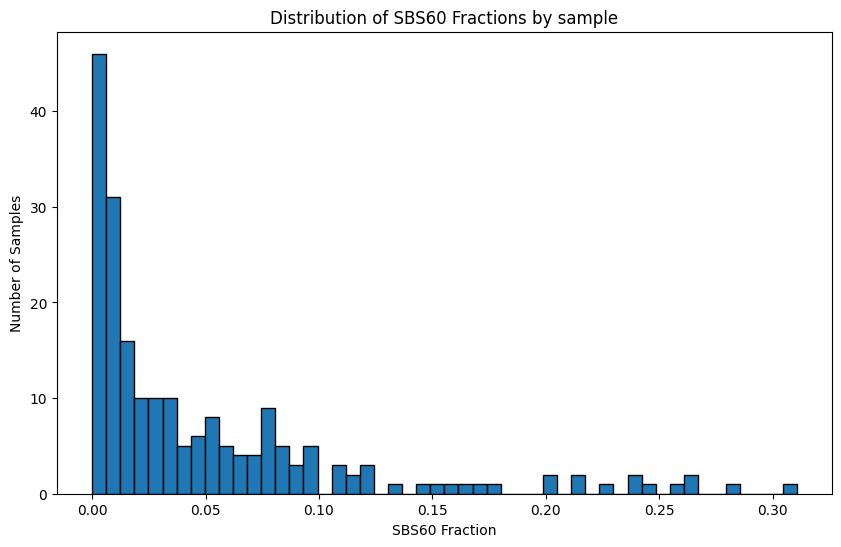

In [112]:
# H matrix has samples as rows, signatures as columns
sbs60_col = [c for c in H.columns if 'S18' in c][0]

total_per_sample = H.sum(axis=1) # calculate total mutations per sample
sbs60_fraction = H[sbs60_col] / total_per_sample

# Create summary
sample_artifact_summary = pd.DataFrame({
    'sample': H.index,
    'sbs60_exposure': H[sbs60_col].values,
    'total_exposure': total_per_sample.values,
    'sbs60_fraction': sbs60_fraction.values
}).sort_values('sbs60_fraction', ascending=False)

# High artifact samples (e.g., >20% SBS60)
high_artifact = sample_artifact_summary[sample_artifact_summary['sbs60_fraction'] > 0.15]
print(f"Samples with >15% SBS60: {len(high_artifact)}")
print(high_artifact.head(20))

# plot the distribution of SBS60 fractions
plt.figure(figsize=(10, 6))
plt.hist(sample_artifact_summary['sbs60_fraction'], bins=50, edgecolor='black')
plt.xlabel('SBS60 Fraction')
plt.ylabel('Number of Samples')
plt.title('Distribution of SBS60 Fractions by sample')
plt.show()

- Consider filtering out samples with high SBS60 fraction (>20% is 13 samples)
- A lot of the high SBS60 fraction samples are from the ICGC cohort